[[ 0.          0.        ]
 [ 7.47694166  0.91386098]
 [ 7.47242757  0.91385062]
 [14.94936923  1.8277116 ]]
[[0.5        0.5       ]
 [0.99943433 0.71378959]
 [0.99943178 0.71378747]
 [0.99999968 0.86148889]]
[[-3.04569685]
 [ 2.32827848]
 [ 2.32828106]
 [-2.0103148 ]]
[[0.04540362]
 [0.91119213]
 [0.91119234]
 [0.11812418]]
Input: [0 0], Predicted Output: [0.0453982], Expected Output: [0]
Input: [0 1], Predicted Output: [0.91120019], Expected Output: [1]
Input: [1 0], Predicted Output: [0.9112004], Expected Output: [1]
Input: [1 1], Predicted Output: [0.11811357], Expected Output: [0]

Final Weights and Biases:
Weights Input-Hidden:
 [[7.47252286 0.91385569]
 [7.47703653 0.91386604]]
Weights Hidden-Output:
 [[ 23.37364587]
 [-29.46528943]]


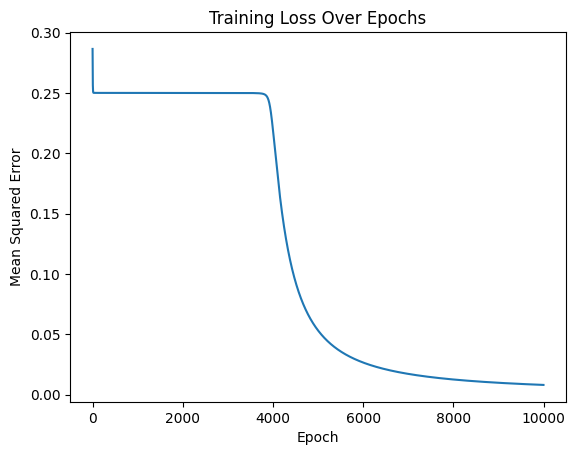

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the sigmoid activation function and its derivative
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# Define the neural network class
# The order of parameters should be input_size followed by hidden_size for the first weight matrix, 
# and hidden_size followed by output_size for the second weight matrix. 
# This is based on the structure of the neural network where the input layer connects to the hidden layer, and the hidden layer connects to the output layer.
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        self.weights_input_hidden = np.random.rand(input_size, hidden_size)
        self.weights_hidden_output = np.random.rand(hidden_size, output_size)

# Define the forward pass and training methods
    def forward(self, inputs):
        hidden_input = np.dot(inputs, self.weights_input_hidden)
        hidden_output = sigmoid(hidden_input) # activation function
        output_input = np.dot(hidden_output, self.weights_hidden_output) # weighted sum
        output = sigmoid(output_input)
        return output

# Define the backpropagation method for training
# The train method combines forward propagation, error calculation, backpropagation, and weight update, 
# which are the key components of the gradient descent optimization process. 
# The weights are iteratively adjusted using this process over multiple epochs to
# gradually improve the network's ability to make accurate predictions.
    def train(self, inputs, targets, epochs):
        loss_history = [] # keep track of loss over epochs
        for _ in range(epochs): # train for a fixed number of epochs
            hidden_input = np.dot(inputs, self.weights_input_hidden) # weighted sum
            hidden_output = sigmoid(hidden_input) # activation function
            output_input = np.dot(hidden_output, self.weights_hidden_output)
            output = sigmoid(output_input)
            error = targets - output # compute error
            d_output = error * sigmoid_derivative(output)
            error_hidden = d_output.dot(self.weights_hidden_output.T) # backpropagate error
            d_hidden = error_hidden * sigmoid_derivative(hidden_output) # compute gradients
            self.weights_hidden_output += hidden_output.T.dot(d_output) # update weights
            self.weights_input_hidden += inputs.T.dot(d_hidden)
            loss = np.mean(np.square(error)) # compute loss
            loss_history.append(loss) # keep track of loss over epochs
        return loss_history

# Example usage
if __name__ == "__main__":
    nn = NeuralNetwork(input_size = 2, hidden_size = 2, output_size = 1) # create neural network
    
    training_inputs = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]) # XOR problem In the XOR problem, the goal is to train a neural network to correctly output the XOR (exclusive OR) of two binary inputs.
    training_targets = np.array([[0], [1], [1], [0]])

    epochs = 10000 # train for 10000 epochs
    loss_history = nn.train(training_inputs, training_targets, epochs) # train neural network

    test_input = np.array([[0, 0]]) # test neural network
    predicted_output = nn.forward(test_input) # make prediction

    # Test the trained network on all inputs
    for test_input in training_inputs:
        predicted_output = nn.forward(test_input)
        expected_output = training_targets[np.where((training_inputs == test_input).all(axis=1))[0][0]]
        print(f"Input: {test_input}, Predicted Output: {predicted_output}, Expected Output: {expected_output}")

    print()
    print("Final Weights and Biases:")
    print("Weights Input-Hidden:\n", nn.weights_input_hidden)
    print("Weights Hidden-Output:\n", nn.weights_hidden_output)

    plt.plot(range(epochs), loss_history) # plot loss over epochs
    plt.xlabel("Epoch")
    plt.ylabel("Mean Squared Error")
    plt.title("Training Loss Over Epochs")
    plt.show()